In [1]:
import numpy as np
import pandas as pd

In [3]:
from Data.data_cleaning import Datacleaner

cleaner = Datacleaner("./Data/Datasets/ligue1_2010_2025.csv")

cleaner = (cleaner.drop_useless_columns()
           .drop_rows(row_idxs=[1520,2281])
           .fillNA(column='Div',value='F1')
           .fillNA(column='Time', value='00:00')
           .add_season())

cleaner.save_data("Data/Datasets/Match_dataset_clean.csv")

c:\Leo_Perso\ENSAE\3A\Advanced ML\Projet ML\Learning-Latent-Football-Team-Strengths\Data\data_cleaning.py:26: DtypeWarning: Columns (139) have mixed types. Specify dtype option on import or set low_memory=False.
  self.df = pd.read_csv(filepath)


In [2]:
from Data.data_preparing import DataPreparer

preparer = DataPreparer(match_data_filepath="Data/Datasets/Match_dataset_clean.csv",
                        market_value_filepath="Data/Datasets/ligue1_market_values_2010_2025.csv")

# Save Features DataFrame
preparer.feature_engineering(save=True, display=False)

df = preparer.merge_df(save=True)

Processing complete. Saving merged dataframe to 'Complete_df.csv'.


In [3]:
from Data.data_processing import DataProcesser

processer = DataProcesser("Data/Datasets/Complete_df.csv")

train_df, test_df = processer.split_train_test(test_season='24-25')

train_data_BT, test_data = processer.get_train_test_data_BT()

feature_names = [
    'Log_Market_Value',     
    'Strength_Rank_Based',   
    'Pythagorean_Exp',       
    'Avg_Goals_Scored',      
    'Home_Dependency',
    'Avg_Shots_Target',  
    'Avg_Corners',       
    'Avg_Cards'        
    ]

train_data_NBTR = processer.get_data_NBTR(feature_names=feature_names)

In [4]:
train_data_NBTR

{'X_home': array([[4.2069287 , 0.05      , 0.35      , ..., 4.3466916 , 4.8899503 ,
         2.145836  ],
        [3.8416007 , 0.05      , 0.35      , ..., 4.3466916 , 4.8899503 ,
         2.145836  ],
        [5.2535815 , 0.05      , 0.35      , ..., 4.3466916 , 4.8899503 ,
         2.145836  ],
        ...,
        [5.990339  , 0.71428573, 0.5929332 , ..., 5.5263157 , 4.368421  ,
         2.0526316 ],
        [4.9093404 , 0.47619048, 0.5       , ..., 4.6842103 , 4.6578946 ,
         2.5789473 ],
        [4.9849753 , 0.3809524 , 0.4446154 , ..., 4.8157897 , 5.2894735 ,
         1.8947369 ]], shape=(5145, 8), dtype=float32),
 'X_away': array([[4.154969  , 0.05      , 0.35      , ..., 4.3466916 , 4.8899503 ,
         2.145836  ],
        [3.9824815 , 0.05      , 0.35      , ..., 4.3466916 , 4.8899503 ,
         2.145836  ],
        [4.335983  , 0.05      , 0.35      , ..., 4.3466916 , 4.8899503 ,
         2.145836  ],
        ...,
        [4.8433995 , 0.23809524, 0.31156123, ..., 4.1842

In [ ]:
from BradleyTerry_classical.functions import BT_calibrate

# Calibrate Hyperparameter Lambda

Lambda_Chooser = BT_calibrate(train_data=train_data_BT)

lambda_grid = np.linspace(-3,2,30)

Lambda_Chooser.calibrate_lambda(lambda_grid=lambda_grid)

In [5]:
from BradleyTerry_classical.BT_classical import BradleyTerry

# Train the model
bt_model = BradleyTerry(lambda_draw=-0.24, learning_rate=0.01, n_iterations=1000)
bt_model.fit(train_data=train_data_BT)

strength = bt_model.predict_strength()

Tolerance threshold attained after 333 iterations
Model fitted successfully !


In [7]:
from Neural_Bradley_Terry.NeuralBT import NeuralBradleyTerry, get_start_year

NBTR_model = NeuralBradleyTerry(input_dim=train_data_NBTR['input_dim'])

NBTR_model.fit(train_data_NBTR['X_home'], train_data_NBTR['X_away'], train_data_NBTR['y'], train_data_NBTR['seasons'], epochs=500)


Training with time-decayed weights


<bound method Module.parameters of NeuralBradleyTerry(
  (feature_extractor): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=1, bias=True)
  )
  (loss_fn): BCEWithLogitsLoss()
)>

Number of matches (Before 24-25) : 5145
Used seasons : ['10-11' '11-12' '12-13' '13-14' '14-15' '15-16' '16-17' '17-18' '18-19'
 '19-20' '20-21' '21-22' '22-23' '23-24']
Training with time-decayed weights


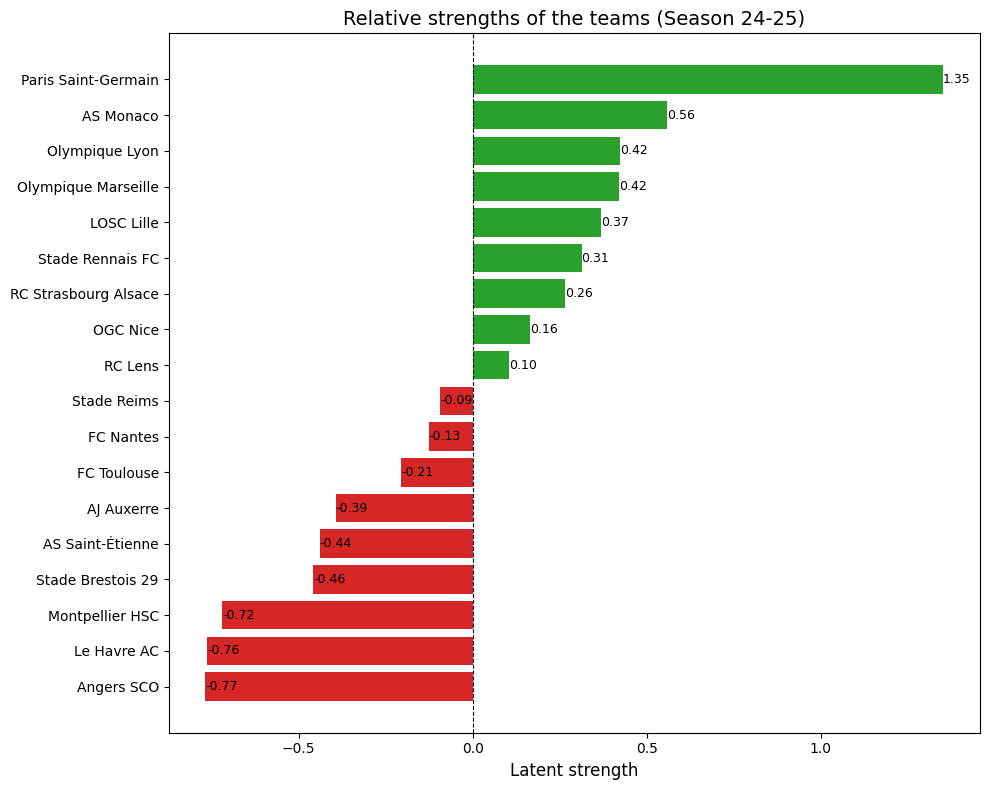

In [17]:
import matplotlib.pyplot as plt

# Used features (every variable is explicitly named in the dataset)
feature_names = [
    'Log_Market_Value',     
    'Strength_Rank_Based',   
    'Pythagorean_Exp',       
    'Avg_Goals_Scored',      
    'Home_Dependency',
    'Avg_Shots_Target',  
    'Avg_Corners',       
    'Avg_Cards'        
    ]

target_season = '24-25' 

model = NeuralBradleyTerry(input_dim=len(feature_names))

# Training data (all seasons before the target season)
df_train = df[df['Season'] != target_season].copy()
target_year =get_start_year(target_season)
df_train = df[df['Season'].apply(get_start_year) < target_year].copy()

# Info to be sure of the data used

print(f"Number of matches (Before {target_season}) : {len(df_train)}")
print(f"Used seasons : {df_train['Season'].unique()}")
seasons = df_train['Season'].values

X_home = df_train[[f"{col}_Home" for col in feature_names]].values.astype(np.float32)
X_away = df_train[[f"{col}_Away" for col in feature_names]].values.astype(np.float32)
y = df_train['Target'].values.astype(np.float32)

# Training loop and print results


model.fit(X_home, X_away, y, seasons, epochs=500)

ranking = model.get_season_ranking(df, target_season, feature_names)

if ranking is not None:
    mean_strength = ranking['Neural_Strength'].mean()
    ranking['Centered_Strength'] = ranking['Neural_Strength'] - mean_strength # Centering around the mean
    plt.figure(figsize=(10, 8))
    df_plot = ranking.head(18).copy() #18 teams in the french league
    colors = ['#2ca02c' if x > 0 else '#d62728' for x in df_plot['Centered_Strength']]
    plt.barh(df_plot['Team'], df_plot['Centered_Strength'], color=colors)
    plt.axvline(0, color='black', linewidth=0.8, linestyle='--') 
    plt.gca().invert_yaxis() 
    plt.title(f"Relative strengths of the teams (Season {target_season})", fontsize=14)
    plt.xlabel("Latent strength", fontsize=12)
    for index, value in enumerate(df_plot['Centered_Strength']):
        plt.text(value, index, f"{value:.2f}", va='center', fontsize=9)
    plt.tight_layout()
    plt.show()

# Simulation part 

# Thresholds can be adjusted to simulate more or less draws
df_probas = model.predict_season_probas(df, target_season, feature_names, draw_threshold=0.5, home_advantage=0.3)

if df_probas is not None:
    df_probas.to_csv(f"Predictions_{target_season}.csv", index=False)

In [23]:
# Probas de matchs

BT_probas = bt_model.simulate_season(list_teams=test_data['Teams'])
BT_probas
NBTR_probas = df_probas
NBTR_probas

,HomeTeam,AwayTeam,P_Home,P_Draw,P_Away,Strength_Diff
0,Le Havre AC,Stade Brestois 29,0.376548,0.244918,0.378535,-0.304227
1,Le Havre AC,Stade Reims,0.295560,0.237260,0.467180,-0.668531
2,Le Havre AC,AS Monaco,0.179449,0.193383,0.627168,-1.320085
3,Le Havre AC,AJ Auxerre,0.361704,0.244653,0.393643,-0.367975
4,Le Havre AC,Angers SCO,0.451514,0.239624,0.308862,0.005444
...,...,...,...,...,...,...
301,Olympique Marseille,AS Saint-Étienne,0.658980,0.181091,0.159930,0.858752
302,Olympique Marseille,RC Lens,0.528716,0.224342,0.246942,0.314991
303,Olympique Marseille,FC Nantes,0.585654,0.207825,0.206521,0.546027
304,Olympique Marseille,OGC Nice,0.513595,0.228023,0.258382,0.254393


In [28]:
# Strengths
BT_strength = strength

NBTR_strength = ranking.copy()

NBTR_strength = NBTR_strength[['Team','Centered_Strength']]

NBTR_strength

,Team,Centered_Strength
5154,Paris Saint-Germain,1.350926
5148,AS Monaco,0.558031
5155,Olympique Lyon,0.423528
5162,Olympique Marseille,0.419362
5156,LOSC Lille,0.367731
5153,Stade Rennais FC,0.312727
5161,RC Strasbourg Alsace,0.264346
5160,OGC Nice,0.164969
5158,RC Lens,0.104372
5147,Stade Reims,-0.093523


In [29]:
from Test.test_BT_classical import BT_evaluate_strengths

Evaluate = BT_evaluate_strengths(BT_results=BT_strength, NBTR_results=NBTR_strength, test_df=test_df)

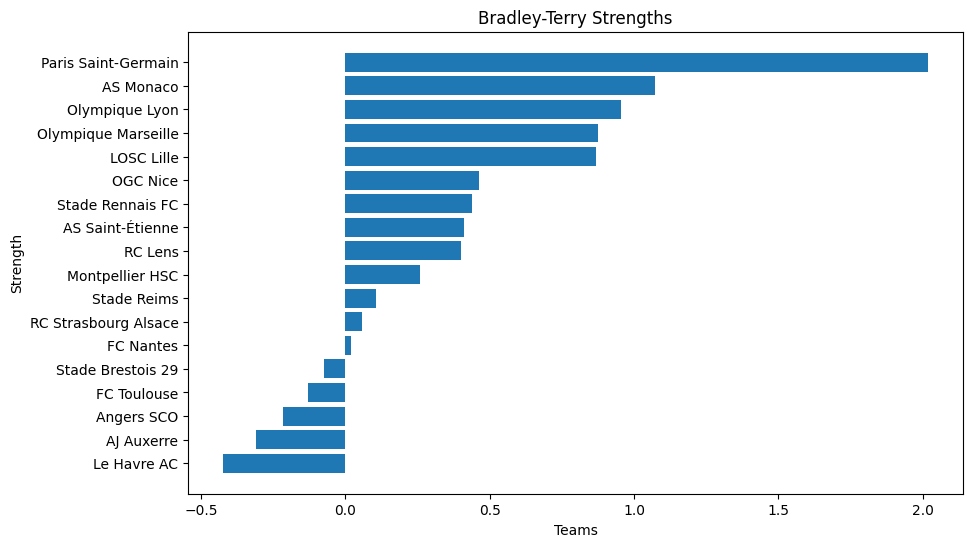

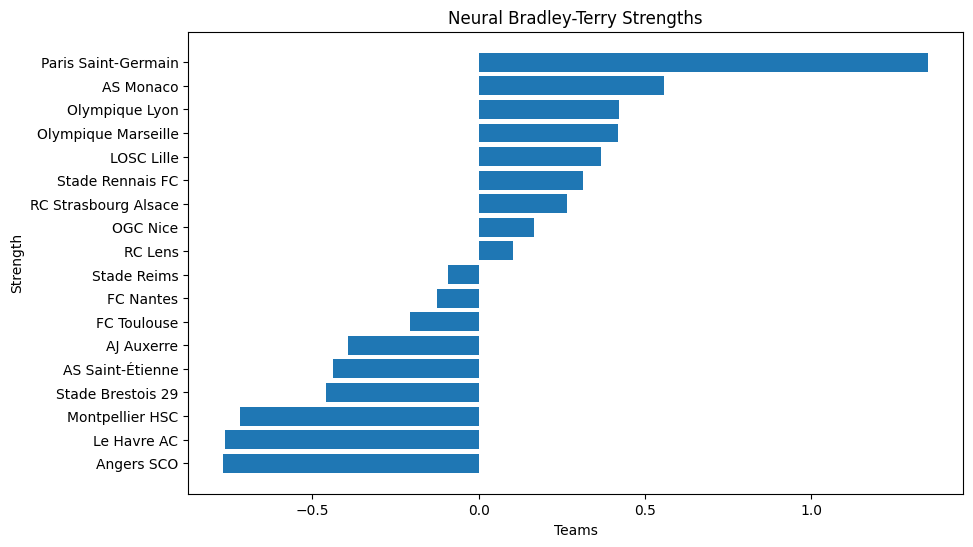

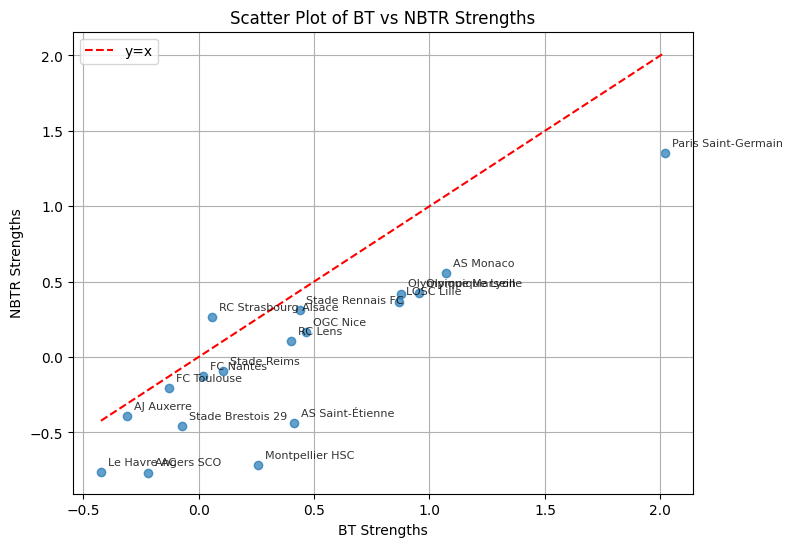

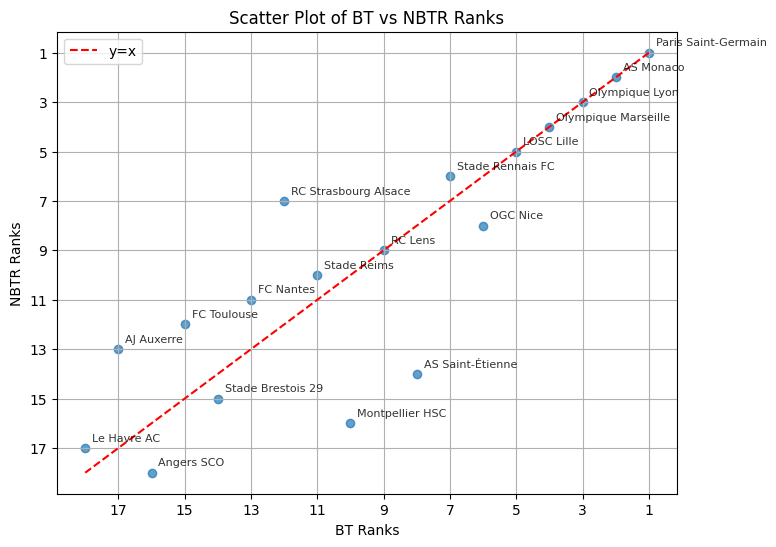

Pearson correlation: {'correlation': np.float64(0.8774591690848056), 'pvalue': np.float64(1.7287019875251824e-06), 'ci_lower': np.float64(0.6442840554800762), 'ci_upper': np.float64(0.9706788944577763)}
Spearman correlation: {'correlation': np.float64(0.8575851393188855), 'pvalue': np.float64(5.3892599467414964e-06), 'ci_lower': np.float64(0.5804339281247666), 'ci_upper': np.float64(0.979145485749044)}
Results correlation (points, BT): {'correlation': np.float64(0.6390913358878553), 'pvalue': np.float64(0.004299097971605389), 'ci_lower': np.float64(0.1549863444001579), 'ci_upper': np.float64(0.881702315361465)}
Results correlation (points, NBTR): {'correlation': np.float64(0.8024836191730998), 'pvalue': np.float64(6.136577777702416e-05), 'ci_lower': np.float64(0.5084366621071746), 'ci_upper': np.float64(0.9241705364221237)}
Results correlation (points, BT): {'correlation': np.float64(0.6829379562335968), 'pvalue': np.float64(0.0017862357741969576), 'ci_lower': np.float64(0.245766566061

In [31]:
# Test all methods of BT_evaluate_strengths

# Plot strengths for BT
Evaluate.plot_strengths('BT')

# Plot strengths for NBTR
Evaluate.plot_strengths('NBTR')

# Scatter plot of strengths
Evaluate.plot_scatter_strengths()

# Scatter plot of ranks
Evaluate.plot_scatter_ranks()

# Pearson correlation
print("Pearson correlation:", Evaluate.pearson_correlation())

# Spearman correlation
print("Spearman correlation:", Evaluate.spearman_correlation())

# Results correlation for points
print("Results correlation (points, BT):", Evaluate.results_correlation('BT', 'points'))
print("Results correlation (points, NBTR):", Evaluate.results_correlation('NBTR', 'points'))

print("Results correlation (points, BT):", Evaluate.results_correlation('BT', 'winrate'))
print("Results correlation (points, NBTR):", Evaluate.results_correlation('NBTR', 'winrate'))

In [32]:
from Test.test_BT_classical import BT_evaluate_probas

evaluator_probas = BT_evaluate_probas(BT_results=BT_probas, NBTR_results=NBTR_probas, test_df=test_df)

Log-loss BT: 1.005558437525326
Log-loss NBTR: 0.9510202455381367
Accuracy BT: 0.5228758169934641
Recall BT: {'H': np.float64(0.6433566433566433), 'D': np.float64(0.0), 'A': np.float64(0.6732673267326733)}
Precision BT: {'H': np.float64(0.6013071895424836), 'D': 0.0, 'A': np.float64(0.4444444444444444)}
Brier score BT: 0.601911069458055
Reliability curve BT shape: (10, 4)
Reliability curve NBTR shape: (10, 4)


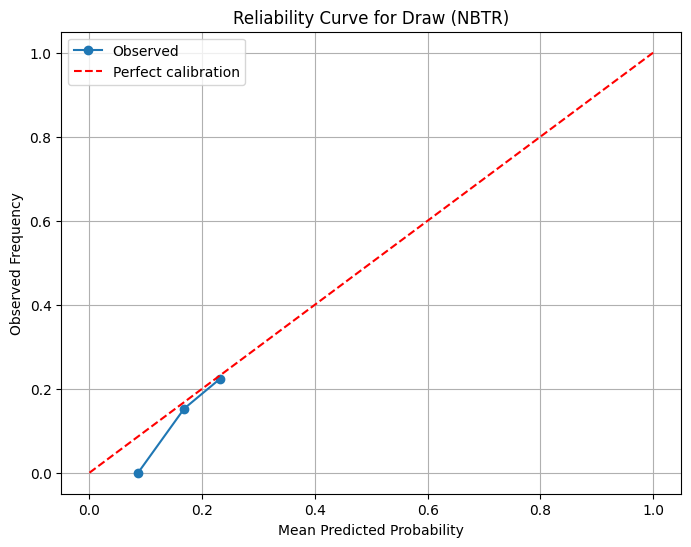

,bin_center,mean_pred_prob,observed_freq,bin_size
0,0.05,0.086318,0.000000,5
1,0.15,0.168160,0.152778,72
2,0.25,0.230813,0.222707,229
3,0.35,NaN,NaN,0
4,0.45,NaN,NaN,0
5,0.55,NaN,NaN,0
6,0.65,NaN,NaN,0
7,0.75,NaN,NaN,0
8,0.85,NaN,NaN,0
9,0.95,NaN,NaN,0


In [ ]:
# Test all methods of BT_evaluate_probas

print("Log-loss BT:", evaluator_probas.logloss('BT'))
print("Log-loss NBTR:", evaluator_probas.logloss('NBTR'))

print("Accuracy BT:", evaluator_probas.accuracy('BT'))
'''print("Accuracy NBTR:", evaluator_probas.accuracy('NBTR'))'''

print("Recall BT:", evaluator_probas.recall('BT'))
'''print("Recall NBTR:", evaluator_probas.recall('NBTR'))'''

print("Precision BT:", evaluator_probas.precision('BT'))
'''print("Precision NBTR:", evaluator_probas.precision('NBTR'))'''

print("Brier score BT:", evaluator_probas.brier_score('BT'))
'''print("Brier score NBTR:", evaluator_probas.brier_score('NBTR'))'''

# Reliability curve (without plotting)
curve_bt = evaluator_probas.reliability_curve_draw('BT', plot=False)
print("Reliability curve BT shape:", curve_bt.shape)

curve_nbtr = evaluator_probas.reliability_curve_draw('NBTR', plot=False)
print("Reliability curve NBTR shape:", curve_nbtr.shape)

# Optional: plot reliability curve
evaluator_probas.reliability_curve_draw('BT', plot=True)